# 1. 우선 게임 코드 & 임베딩벡터 생성

In [ ]:
import random
import math

# ----- 확률 파라미터 -----
p = 1 / 125
q = 1 - p

total = int(input("얼마를 충전하시겠습니까? "))
jackpot_num_list = []
previous_betting = 0

# 구간 정의(양끝 포함)
intervals = [(1, 28), (29, 64), (65, 115), (116, 200), (201, float('inf'))]


# ------------------------------
# 임베딩 벡터 관련 함수들
# ------------------------------

def make_jackpot_num():
    """기하분포(p=1/125)를 시뮬레이션해서 첫 잭팟 시점을 반환"""
    jackpot_num = 1
    while True:
        if random.randint(1, 125) == 1:
            return jackpot_num
        jackpot_num += 1

def classify_interval(x, intervals):
    """값 x가 속한 구간의 인덱스(0~len-1)를 반환"""
    for i, (lo, hi) in enumerate(intervals):
        if lo <= x <= hi:
            return i
    return None

def signed_streaks_by_interval(nums, intervals):
    """각 구간의 '부호 있는 스트릭' 계산"""
    seq = [classify_interval(x, intervals) for x in nums]
    m = len(intervals)
    L = len(seq)
    if L == 0:
        return [0] * m

    streaks = []
    for target in range(m):
        if seq[-1] == target:
            r = 0
            j = L - 1
            while j >= 0 and seq[j] == target:
                r += 1
                j -= 1
            streaks.append(+r)
        else:
            g = 0
            j = L - 1
            while j >= 0 and seq[j] != target:
                g += 1
                j -= 1
            streaks.append(-g)
    return streaks

def count_all_intervals(nums, intervals):
    """전체 잭팟 기록에서 각 구간의 누적 출현 횟수 계산"""
    counts = [0] * len(intervals)
    for x in nums:
        idx = classify_interval(x, intervals)
        if idx is not None:
            counts[idx] += 1
    return counts, len(nums)

def get_disappeared_bin(nums, intervals, window_size=5):
    """최근 window_size개 구간 중 사라진 구간 계산"""
    if len(nums) < window_size:
        return None
    old_value = nums[-window_size]
    disappeared_bin = classify_interval(old_value, intervals)
    return disappeared_bin

def moving_average(data, n):
    """최근 n개 평균"""
    if len(data) == 0:
        return 0
    subset = data[-n:] if len(data) >= n else data
    return round(sum(subset) / len(subset))

def interval_distribution(nums, intervals, n):
    """최근 n개 구간 분포"""
    recent = nums[-n:]
    counts = [0] * len(intervals)
    for num in recent:
        idx = classify_interval(num, intervals)
        if idx is not None:
            counts[idx] += 1
    return counts

# ------------------------------
# 30차원 임베딩 벡터 생성 함수
# ------------------------------

def create_embedding_vector(jackpot_num_list, intervals, play_num):
    """
    의미 기반 30차원 임베딩 벡터 생성 (모든 값 소수 둘째 자리 반올림)
    """

    # 1. 최근 구간 분포(5,10,15,20)
    interval_features = []
    for n in [5, 10, 15, 20]:
        interval_features.extend(interval_distribution(jackpot_num_list, intervals, n))

    # 2. 최근 평균 (5, 10, 15, 20)
    avg_features = [moving_average(jackpot_num_list, n) for n in [5, 10, 15, 20]]

    # 3. 구간별 연속정도 (signed streak)
    streak_features = signed_streaks_by_interval(jackpot_num_list, intervals)

    # 4. 당첨 확률 (기하 CDF)
    p = 1/125
    q = 1 - p
    probability_cdf = (1 - (q ** play_num))

    # --- 하나의 임베딩 벡터로 합치기 ---
    embedding_vector = []
    embedding_vector.extend(interval_features)
    embedding_vector.extend(avg_features)
    embedding_vector.extend(streak_features)
    embedding_vector.append(probability_cdf)

    # 🔥 모든 요소 소수 둘째 자리 반올림
    embedding_vector = [round(float(x), 2) for x in embedding_vector]

    return embedding_vector


# ------------------------------
# 메인 게임 함수
# ------------------------------

def slot_machine():
    global total, previous_betting, jackpot_num_list
    jackpot_num = make_jackpot_num()
    play_num = 0

    while True:
        betting_str = input("얼마를 배팅 하시겠습니까? ")

        if betting_str == '':
            if previous_betting == 0:
                print("이전 배팅 금액이 없습니다. 배팅 금액을 입력해주세요.")
                continue
            else:
                betting = previous_betting
        else:
            try:
                betting = int(betting_str)
                if betting <= 0:
                    print("배팅 금액은 0보다 커야 합니다.")
                    continue
            except ValueError:
                print("유효한 배팅 금액을 입력해주세요.")
                continue

        if betting > total:
            print("배팅 금액이 잔액을 초과합니다.")
            continue

        previous_betting = betting
        play_num += 1
        total -= betting

        probability = (1 - (q ** play_num)) * 100

        # 💡 구간분포: 5, 10, 15, 20개 기준으로 계산
        interval_counts = {n: interval_distribution(jackpot_num_list, intervals, n) for n in [5, 10, 15, 20]}

        # 💡 이동평균: 5, 10, 15, 20개 기준으로 계산
        averages = {n: moving_average(jackpot_num_list, n) for n in [5, 10, 15, 20]}

        signed_streaks = signed_streaks_by_interval(jackpot_num_list, intervals)
        total_counts, n_total = count_all_intervals(jackpot_num_list, intervals)

        disappeared_bin = get_disappeared_bin(jackpot_num_list, intervals, window_size=5)

        print("\n")
        print(f"현재 {play_num}회 배팅 중입니다. total: {total}")
        for n in [5, 10, 15, 20]:
            print(f"구간분포(최근{n}) {interval_counts[n]}")
        print(f"당첨확률(기하CDF): {probability:.2f}%")

        avg_str = ", ".join([f"{n}개={averages[n]}" for n in [5, 10, 15, 20]])
        print(f"최근 평균: {avg_str}")
        print(f"구간별 연속정도 : {signed_streaks}")
        print(f"전체 {n_total}개 구간별 누적 횟수: {total_counts}")

        if disappeared_bin is not None:
            lo, hi = intervals[disappeared_bin]
            print(f"최근 5회 기준 사라진 구간: {disappeared_bin + 1} ({lo}~{hi})")
        else:
            print(f"최근 5회 기준 사라진 구간: 없음 (데이터 부족)")

        print(f"(1,28)(29,64)(65,115)(116,200)(201), 이전 {jackpot_num_list[-5:]}")

        # -------------------------
        # 📌 임베딩 벡터 출력 추가됨!
        # -------------------------
        emb = create_embedding_vector(jackpot_num_list, intervals, play_num)
        print("\n📌 생성된 임베딩벡터 (길이:", len(emb), ")")
        print(emb)
        # -------------------------

        # 🎰 잭팟 처리
        if play_num == jackpot_num:
            total += betting * 110
            jackpot_num_list.append(play_num)
            print(f"이야~ 대박!🧞‍♂️ 축하합니다! 잭팟입니다! total: {total}")
            print("🧚‍♂️ 🧚‍♀️")
            break


# ------------------------------
# 게임 반복 실행
# ------------------------------

while True:
    slot_machine()


# 2. 각 임베딩벡터 요소를 적저히 확률화한 코드

## 1. 구간분포 확률화

In [6]:
# 구간분포 5,10,15,20 모든경우 구간분포 백분율 확률화

import random
from collections import Counter
import pandas as pd

# ----- 확률 파라미터 -----
p = 1 / 125
q = 1 - p

# ----- 구간 정의 -----
intervals = [
    (1, 28),
    (29, 64),
    (65, 115),
    (116, 200),
    (201, float('inf'))
]

# ----- 잭팟 생성 -----
def make_jackpot_num():
    jackpot_num = 1
    while True:
        if random.randint(1, 125) == 1:
            return jackpot_num
        jackpot_num += 1

# ----- 구간 판별 -----
def classify_interval(x, intervals):
    for i, (lo, hi) in enumerate(intervals):
        if lo <= x <= hi:
            return i
    return None

# ----- 최근 n개 구간분포 패턴 -----
def interval_histogram(nums, intervals, n):
    recent = nums[-n:]
    counts = [0] * len(intervals)
    for x in recent:
        idx = classify_interval(x, intervals)
        if idx is not None:
            counts[idx] += 1
    return tuple(counts)

# ----- 시뮬레이션 -----
def simulate_pattern_counts(n_jackpots, window_size):
    jackpot_nums = []
    pattern_counter = Counter()

    for _ in range(n_jackpots):
        jackpot = make_jackpot_num()
        jackpot_nums.append(jackpot)

        if len(jackpot_nums) >= window_size:
            pattern = interval_histogram(jackpot_nums, intervals, window_size)
            if sum(pattern) == window_size:
                pattern_counter[pattern] += 1

    return pattern_counter

# ----- 확률 테이블로 변환 (퍼센트 단위) -----
def make_percent_table(pattern_counter):
    total = sum(pattern_counter.values())
    table = {}

    for pattern, count in pattern_counter.items():
        percent = (count / total) * 100
        table[pattern] = round(percent, 4)  # 퍼센트 단위
    return table

# ----- 출력 -----
def show_table(percent_table, label):
    df = pd.DataFrame([(pattern, percent_table[pattern]) for pattern in percent_table],
                      columns=["Pattern", "Probability(%)"]) \
         .sort_values("Probability(%)", ascending=False) \
         .reset_index(drop=True)

    print(f"\n=== 🔥 {label} 구간분포 확률 테이블 ===")
    print(df)
    print(f"총 {len(df)}가지 패턴\n")

# ============================================================
# 🔥 통합 실행
# ============================================================

N = int(input("생성할 잭팟 개수를 입력하세요: "))
windows = [5, 10, 15, 20]

percent_tables = {}

for w in windows:
    patterns = simulate_pattern_counts(N, window_size=w)
    percent_tables[w] = make_percent_table(patterns)
    show_table(percent_tables[w], f"최근 {w}개")

print("\n🎯 모든 확률 테이블 생성 완료!")


생성할 잭팟 개수를 입력하세요:  200000



=== 🔥 최근 5개 구간분포 확률 테이블 ===
             Pattern  Probability(%)
0    (1, 1, 1, 1, 1)          3.7826
1    (2, 1, 1, 0, 1)          2.0130
2    (0, 1, 1, 1, 2)          1.9695
3    (1, 1, 1, 0, 2)          1.9680
4    (0, 1, 2, 1, 1)          1.9560
..               ...             ...
121  (5, 0, 0, 0, 0)          0.0375
122  (0, 5, 0, 0, 0)          0.0350
123  (0, 0, 0, 0, 5)          0.0330
124  (0, 0, 5, 0, 0)          0.0285
125  (0, 0, 0, 5, 0)          0.0225

[126 rows x 2 columns]
총 126가지 패턴


=== 🔥 최근 10개 구간분포 확률 테이블 ===
             Pattern  Probability(%)
0    (2, 2, 2, 2, 2)          1.1916
1    (2, 3, 2, 1, 2)          0.8365
2    (1, 2, 3, 2, 2)          0.7985
3    (3, 2, 2, 1, 2)          0.7970
4    (1, 2, 2, 2, 3)          0.7915
..               ...             ...
957  (0, 0, 0, 2, 8)          0.0005
958  (0, 0, 0, 1, 9)          0.0005
959  (1, 0, 0, 0, 9)          0.0005
960  (8, 1, 0, 0, 1)          0.0005
961  (0, 1, 8, 0, 1)          0.0005

[962 rows x 2 co

## 2. 최근 평균 확률화
- PDF인데 이건 CDF로 확률화 완성해서 신경망에 넣어야겠다.

Enter number of simulations:  200000


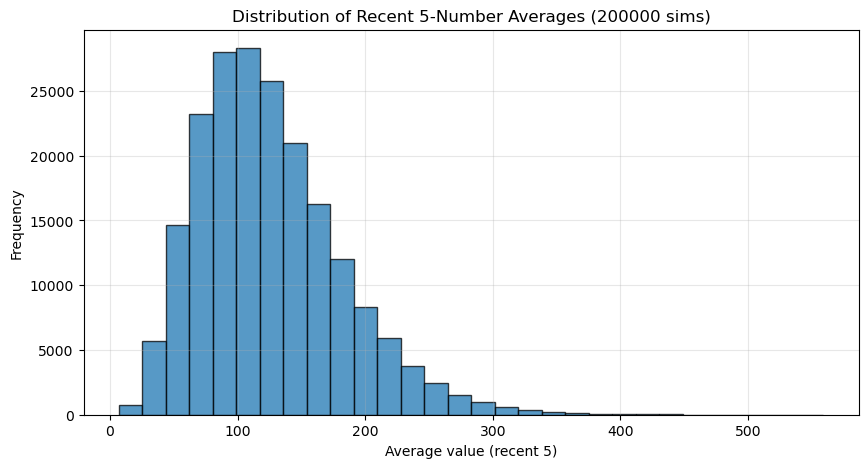


=== 확률 구간표 (자연수 반올림된 구간) ===
Bin  0:  [  7 ~  25]   Count =    727   Prob =  0.364%
Bin  1:  [ 25 ~  44]   Count =   5724   Prob =  2.862%
Bin  2:  [ 44 ~  62]   Count =  14627   Prob =  7.314%
Bin  3:  [ 62 ~  81]   Count =  23174   Prob = 11.587%
Bin  4:  [ 81 ~  99]   Count =  27985   Prob = 13.993%
Bin  5:  [ 99 ~ 117]   Count =  28302   Prob = 14.151%
Bin  6:  [117 ~ 136]   Count =  25775   Prob = 12.888%
Bin  7:  [136 ~ 154]   Count =  20946   Prob = 10.473%
Bin  8:  [154 ~ 173]   Count =  16233   Prob =  8.117%
Bin  9:  [173 ~ 191]   Count =  12019   Prob =  6.010%
Bin 10:  [191 ~ 209]   Count =   8313   Prob =  4.157%
Bin 11:  [209 ~ 228]   Count =   5885   Prob =  2.943%
Bin 12:  [228 ~ 246]   Count =   3730   Prob =  1.865%
Bin 13:  [246 ~ 265]   Count =   2462   Prob =  1.231%
Bin 14:  [265 ~ 283]   Count =   1530   Prob =  0.765%
Bin 15:  [283 ~ 301]   Count =    991   Prob =  0.496%
Bin 16:  [301 ~ 320]   Count =    621   Prob =  0.311%
Bin 17:  [320 ~ 338]   Count =    3

In [2]:
import random
import matplotlib.pyplot as plt
import numpy as np

# ----- Probability parameter -----
p = 1 / 125
q = 1 - p

def make_jackpot_num():
    jackpot_num = 1
    while True:
        if random.randint(1, 125) == 1:
            return jackpot_num
        jackpot_num += 1

def moving_average_last_n(data, n=5):
    if len(data) < n:
        return None
    return sum(data[-n:]) / n

def compute_pdf(values, bins=30):
    counts, bin_edges = np.histogram(values, bins=bins)
    total = np.sum(counts)
    pdf = counts / total
    return pdf, bin_edges, counts

def get_probability(avg_value, pdf, bin_edges):
    for i in range(len(bin_edges)-1):
        if bin_edges[i] <= avg_value < bin_edges[i+1]:
            lo = int(round(bin_edges[i]))
            hi = int(round(bin_edges[i+1]))
            return pdf[i], (lo, hi), i
    lo = int(round(bin_edges[-2]))
    hi = int(round(bin_edges[-1]))
    return pdf[-1], (lo, hi), len(bin_edges)-2

def simulate_and_plot(num_simulations, window_size=5, bins=30):
    jackpot_nums = []
    avg_history = []

    for _ in range(num_simulations):
        jn = make_jackpot_num()
        jackpot_nums.append(jn)

        avg_value = moving_average_last_n(jackpot_nums, window_size)
        if avg_value is not None:
            avg_history.append(avg_value)

    plt.figure(figsize=(10, 5))
    plt.hist(avg_history, bins=bins, edgecolor='black', alpha=0.75)
    plt.title(f"Distribution of Recent {window_size}-Number Averages ({num_simulations} sims)")
    plt.xlabel(f"Average value (recent {window_size})")
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)
    plt.show()

    pdf, bin_edges, counts = compute_pdf(avg_history, bins=bins)

    print("\n=== 확률 구간표 (자연수 반올림된 구간) ===")
    for i in range(bins):
        lo = int(round(bin_edges[i]))
        hi = int(round(bin_edges[i+1]))
        print(f"Bin {i:2d}:  [{lo:3d} ~ {hi:3d}]   Count = {counts[i]:6d}   Prob = {pdf[i]*100:6.3f}%")

    return avg_history, pdf, bin_edges

# Run
num_sim = int(input("Enter number of simulations: "))
avg_history, pdf, bins = simulate_and_plot(num_sim, window_size=5, bins=30)

test_avg = 125
prob, (lo, hi), idx = get_probability(test_avg, pdf, bins)

print(f"\n입력 평균값 {test_avg} → Bin {idx}")
print(f"구간 = [{lo} ~ {hi}]")
print(f"확률 = {prob*100:.3f}%")


Enter number of simulations:  200000


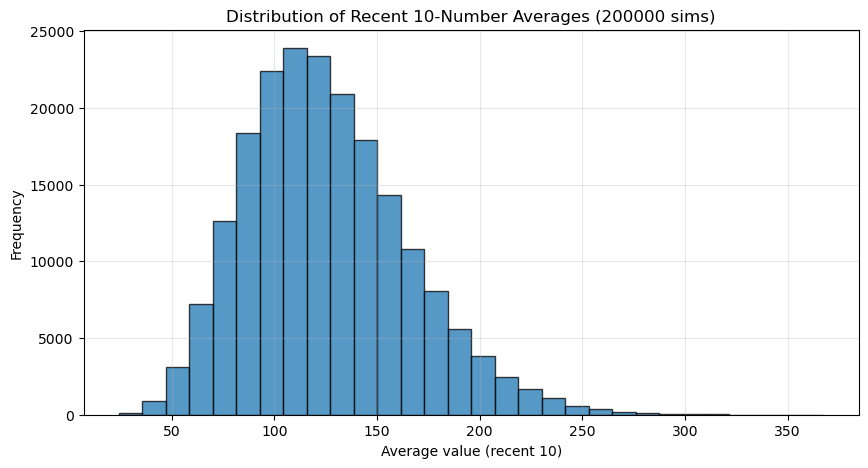


=== 확률 구간표 (자연수 반올림된 구간) ===
Bin  0:  [ 24 ~  36]   Count =    138   Prob =  0.069%
Bin  1:  [ 36 ~  47]   Count =    918   Prob =  0.459%
Bin  2:  [ 47 ~  59]   Count =   3138   Prob =  1.569%
Bin  3:  [ 59 ~  70]   Count =   7220   Prob =  3.610%
Bin  4:  [ 70 ~  81]   Count =  12623   Prob =  6.312%
Bin  5:  [ 81 ~  93]   Count =  18360   Prob =  9.180%
Bin  6:  [ 93 ~ 104]   Count =  22399   Prob = 11.200%
Bin  7:  [104 ~ 116]   Count =  23893   Prob = 11.947%
Bin  8:  [116 ~ 127]   Count =  23346   Prob = 11.674%
Bin  9:  [127 ~ 139]   Count =  20871   Prob = 10.436%
Bin 10:  [139 ~ 150]   Count =  17889   Prob =  8.945%
Bin 11:  [150 ~ 162]   Count =  14299   Prob =  7.150%
Bin 12:  [162 ~ 173]   Count =  10811   Prob =  5.406%
Bin 13:  [173 ~ 184]   Count =   8041   Prob =  4.021%
Bin 14:  [184 ~ 196]   Count =   5594   Prob =  2.797%
Bin 15:  [196 ~ 207]   Count =   3809   Prob =  1.905%
Bin 16:  [207 ~ 219]   Count =   2479   Prob =  1.240%
Bin 17:  [219 ~ 230]   Count =   16

In [3]:
import random
import matplotlib.pyplot as plt
import numpy as np

# ----- Probability parameter -----
p = 1 / 125
q = 1 - p

def make_jackpot_num():
    jackpot_num = 1
    while True:
        if random.randint(1, 125) == 1:
            return jackpot_num
        jackpot_num += 1

def moving_average_last_n(data, n=10):   # ← 5 → 10으로 변경
    if len(data) < n:
        return None
    return sum(data[-n:]) / n

def compute_pdf(values, bins=30):
    counts, bin_edges = np.histogram(values, bins=bins)
    total = np.sum(counts)
    pdf = counts / total
    return pdf, bin_edges, counts

def get_probability(avg_value, pdf, bin_edges):
    for i in range(len(bin_edges)-1):
        if bin_edges[i] <= avg_value < bin_edges[i+1]:
            lo = int(round(bin_edges[i]))
            hi = int(round(bin_edges[i+1]))
            return pdf[i], (lo, hi), i
    lo = int(round(bin_edges[-2]))
    hi = int(round(bin_edges[-1]))
    return pdf[-1], (lo, hi), len(bin_edges)-2

def simulate_and_plot(num_simulations, window_size=10, bins=30):  # ← 5 → 10
    jackpot_nums = []
    avg_history = []

    for _ in range(num_simulations):
        jn = make_jackpot_num()
        jackpot_nums.append(jn)

        avg_value = moving_average_last_n(jackpot_nums, window_size)
        if avg_value is not None:
            avg_history.append(avg_value)

    plt.figure(figsize=(10, 5))
    plt.hist(avg_history, bins=bins, edgecolor='black', alpha=0.75)
    plt.title(f"Distribution of Recent {window_size}-Number Averages ({num_simulations} sims)")
    plt.xlabel(f"Average value (recent {window_size})")
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)
    plt.show()

    pdf, bin_edges, counts = compute_pdf(avg_history, bins=bins)

    print("\n=== 확률 구간표 (자연수 반올림된 구간) ===")
    for i in range(bins):
        lo = int(round(bin_edges[i]))
        hi = int(round(bin_edges[i+1]))
        print(f"Bin {i:2d}:  [{lo:3d} ~ {hi:3d}]   Count = {counts[i]:6d}   Prob = {pdf[i]*100:6.3f}%")

    return avg_history, pdf, bin_edges

# Run
num_sim = int(input("Enter number of simulations: "))
avg_history, pdf, bins = simulate_and_plot(num_sim, window_size=10, bins=30)

test_avg = 125
prob, (lo, hi), idx = get_probability(test_avg, pdf, bins)

print(f"\n입력 평균값 {test_avg} → Bin {idx}")
print(f"구간 = [{lo} ~ {hi}]")
print(f"확률 = {prob*100:.3f}%")


Enter number of simulations:  200000


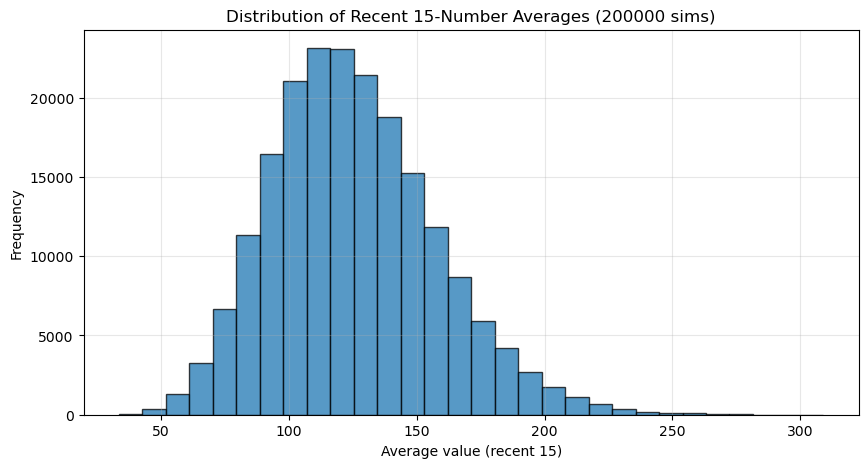


=== 확률 구간표 (자연수 반올림된 구간) ===
Bin  0:  [ 33 ~  43]   Count =     54   Prob =  0.027%
Bin  1:  [ 43 ~  52]   Count =    364   Prob =  0.182%
Bin  2:  [ 52 ~  61]   Count =   1328   Prob =  0.664%
Bin  3:  [ 61 ~  70]   Count =   3294   Prob =  1.647%
Bin  4:  [ 70 ~  79]   Count =   6695   Prob =  3.348%
Bin  5:  [ 79 ~  89]   Count =  11345   Prob =  5.673%
Bin  6:  [ 89 ~  98]   Count =  16435   Prob =  8.218%
Bin  7:  [ 98 ~ 107]   Count =  21079   Prob = 10.540%
Bin  8:  [107 ~ 116]   Count =  23135   Prob = 11.568%
Bin  9:  [116 ~ 125]   Count =  23079   Prob = 11.540%
Bin 10:  [125 ~ 134]   Count =  21405   Prob = 10.703%
Bin 11:  [134 ~ 144]   Count =  18795   Prob =  9.398%
Bin 12:  [144 ~ 153]   Count =  15277   Prob =  7.639%
Bin 13:  [153 ~ 162]   Count =  11819   Prob =  5.910%
Bin 14:  [162 ~ 171]   Count =   8708   Prob =  4.354%
Bin 15:  [171 ~ 180]   Count =   5926   Prob =  2.963%
Bin 16:  [180 ~ 190]   Count =   4187   Prob =  2.094%
Bin 17:  [190 ~ 199]   Count =   27

In [4]:
import random
import matplotlib.pyplot as plt
import numpy as np

# ----- Probability parameter -----
p = 1 / 125
q = 1 - p

def make_jackpot_num():
    jackpot_num = 1
    while True:
        if random.randint(1, 125) == 1:
            return jackpot_num
        jackpot_num += 1

def moving_average_last_n(data, n=15):   # ← 10 → 15으로 변경
    if len(data) < n:
        return None
    return sum(data[-n:]) / n

def compute_pdf(values, bins=30):
    counts, bin_edges = np.histogram(values, bins=bins)
    total = np.sum(counts)
    pdf = counts / total
    return pdf, bin_edges, counts

def get_probability(avg_value, pdf, bin_edges):
    for i in range(len(bin_edges)-1):
        if bin_edges[i] <= avg_value < bin_edges[i+1]:
            lo = int(round(bin_edges[i]))
            hi = int(round(bin_edges[i+1]))
            return pdf[i], (lo, hi), i
    lo = int(round(bin_edges[-2]))
    hi = int(round(bin_edges[-1]))
    return pdf[-1], (lo, hi), len(bin_edges)-2

def simulate_and_plot(num_simulations, window_size=15, bins=30):  # ← 10 → 15
    jackpot_nums = []
    avg_history = []

    for _ in range(num_simulations):
        jn = make_jackpot_num()
        jackpot_nums.append(jn)

        avg_value = moving_average_last_n(jackpot_nums, window_size)
        if avg_value is not None:
            avg_history.append(avg_value)

    plt.figure(figsize=(10, 5))
    plt.hist(avg_history, bins=bins, edgecolor='black', alpha=0.75)
    plt.title(f"Distribution of Recent {window_size}-Number Averages ({num_simulations} sims)")
    plt.xlabel(f"Average value (recent {window_size})")
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)
    plt.show()

    pdf, bin_edges, counts = compute_pdf(avg_history, bins=bins)

    print("\n=== 확률 구간표 (자연수 반올림된 구간) ===")
    for i in range(bins):
        lo = int(round(bin_edges[i]))
        hi = int(round(bin_edges[i+1]))
        print(f"Bin {i:2d}:  [{lo:3d} ~ {hi:3d}]   Count = {counts[i]:6d}   Prob = {pdf[i]*100:6.3f}%")

    return avg_history, pdf, bin_edges

# Run
num_sim = int(input("Enter number of simulations: "))
avg_history, pdf, bins = simulate_and_plot(num_sim, window_size=15, bins=30)

test_avg = 125
prob, (lo, hi), idx = get_probability(test_avg, pdf, bins)

print(f"\n입력 평균값 {test_avg} → Bin {idx}")
print(f"구간 = [{lo} ~ {hi}]")
print(f"확률 = {prob*100:.3f}%")


Enter number of simulations:  200000


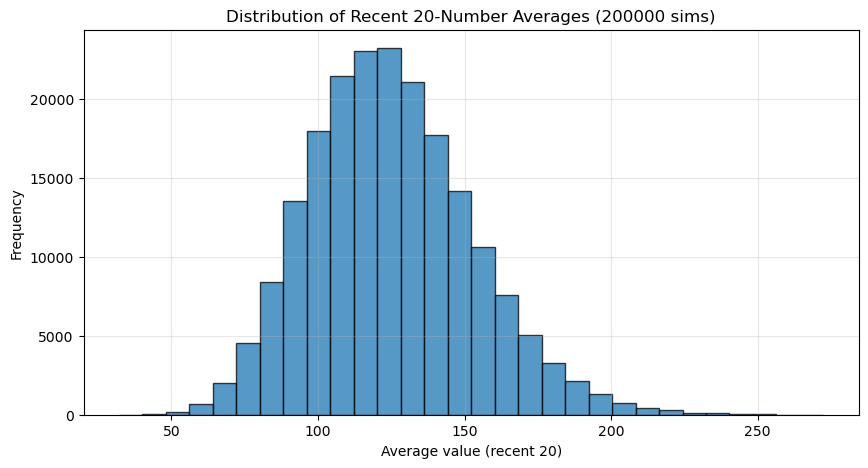


=== 확률 구간표 (자연수 반올림된 구간) ===
Bin  0:  [ 32 ~  40]   Count =      8   Prob =  0.004%
Bin  1:  [ 40 ~  48]   Count =     23   Prob =  0.012%
Bin  2:  [ 48 ~  56]   Count =    159   Prob =  0.080%
Bin  3:  [ 56 ~  64]   Count =    698   Prob =  0.349%
Bin  4:  [ 64 ~  72]   Count =   2001   Prob =  1.001%
Bin  5:  [ 72 ~  80]   Count =   4565   Prob =  2.283%
Bin  6:  [ 80 ~  88]   Count =   8386   Prob =  4.193%
Bin  7:  [ 88 ~  96]   Count =  13584   Prob =  6.793%
Bin  8:  [ 96 ~ 104]   Count =  17995   Prob =  8.998%
Bin  9:  [104 ~ 112]   Count =  21453   Prob = 10.728%
Bin 10:  [112 ~ 120]   Count =  23077   Prob = 11.540%
Bin 11:  [120 ~ 128]   Count =  23253   Prob = 11.628%
Bin 12:  [128 ~ 136]   Count =  21129   Prob = 10.566%
Bin 13:  [136 ~ 144]   Count =  17729   Prob =  8.865%
Bin 14:  [144 ~ 152]   Count =  14168   Prob =  7.085%
Bin 15:  [152 ~ 160]   Count =  10659   Prob =  5.330%
Bin 16:  [160 ~ 168]   Count =   7578   Prob =  3.789%
Bin 17:  [168 ~ 176]   Count =   50

In [5]:
import random
import matplotlib.pyplot as plt
import numpy as np

# ----- Probability parameter -----
p = 1 / 125
q = 1 - p

def make_jackpot_num():
    jackpot_num = 1
    while True:
        if random.randint(1, 125) == 1:
            return jackpot_num
        jackpot_num += 1

def moving_average_last_n(data, n=20):   # ← 20개 평균으로 변경
    if len(data) < n:
        return None
    return sum(data[-n:]) / n

def compute_pdf(values, bins=30):
    counts, bin_edges = np.histogram(values, bins=bins)
    total = np.sum(counts)
    pdf = counts / total
    return pdf, bin_edges, counts

def get_probability(avg_value, pdf, bin_edges):
    for i in range(len(bin_edges)-1):
        if bin_edges[i] <= avg_value < bin_edges[i+1]:
            lo = int(round(bin_edges[i]))
            hi = int(round(bin_edges[i+1]))
            return pdf[i], (lo, hi), i
    lo = int(round(bin_edges[-2]))
    hi = int(round(bin_edges[-1]))
    return pdf[-1], (lo, hi), len(bin_edges)-2

def simulate_and_plot(num_simulations, window_size=20, bins=30):  # ← 20으로 변경
    jackpot_nums = []
    avg_history = []

    for _ in range(num_simulations):
        jn = make_jackpot_num()
        jackpot_nums.append(jn)

        avg_value = moving_average_last_n(jackpot_nums, window_size)
        if avg_value is not None:
            avg_history.append(avg_value)

    plt.figure(figsize=(10, 5))
    plt.hist(avg_history, bins=bins, edgecolor='black', alpha=0.75)
    plt.title(f"Distribution of Recent {window_size}-Number Averages ({num_simulations} sims)")
    plt.xlabel(f"Average value (recent {window_size})")
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)
    plt.show()

    pdf, bin_edges, counts = compute_pdf(avg_history, bins=bins)

    print("\n=== 확률 구간표 (자연수 반올림된 구간) ===")
    for i in range(bins):
        lo = int(round(bin_edges[i]))
        hi = int(round(bin_edges[i+1]))
        print(f"Bin {i:2d}:  [{lo:3d} ~ {hi:3d}]   Count = {counts[i]:6d}   Prob = {pdf[i]*100:6.3f}%")

    return avg_history, pdf, bin_edges

# Run
num_sim = int(input("Enter number of simulations: "))
avg_history, pdf, bins = simulate_and_plot(num_sim, window_size=20, bins=30)

test_avg = 125
prob, (lo, hi), idx = get_probability(test_avg, pdf, bins)

print(f"\n입력 평균값 {test_avg} → Bin {idx}")
print(f"구간 = [{lo} ~ {hi}]")
print(f"확률 = {prob*100:.3f}%")


## 3. 연속정도 확률화

In [7]:
import random

# ----- 확률 파라미터 -----
p = 1 / 125
q = 1 - p

total = int(input("얼마를 충전하시겠습니까? "))
jackpot_num_list = []
previous_betting = 0

# 구간 정의(양끝 포함)
intervals = [(1, 28), (29, 64), (65, 115), (116, 200), (201, float('inf'))]


def make_jackpot_num():
    jackpot_num = 1
    while True:
        if random.randint(1, 125) == 1:
            return jackpot_num
        jackpot_num += 1


def classify_interval(x, intervals):
    for i, (lo, hi) in enumerate(intervals):
        if lo <= x <= hi:
            return i
    return None


def signed_streaks_by_interval(nums, intervals):
    seq = [classify_interval(x, intervals) for x in nums]
    m = len(intervals)
    L = len(seq)
    if L == 0:
        return [0] * m

    streaks = []
    for target in range(m):
        if seq[-1] == target:
            r = 0
            j = L - 1
            while j >= 0 and seq[j] == target:
                r += 1
                j -= 1
            streaks.append(+r)
        else:
            g = 0
            j = L - 1
            while j >= 0 and seq[j] != target:
                g += 1
                j -= 1
            streaks.append(-g)
    return streaks


def softmax(weights):
    total = sum(weights)
    return [w / total for w in weights]


def count_all_intervals(nums, intervals):
    counts = [0] * len(intervals)
    for x in nums:
        idx = classify_interval(x, intervals)
        if idx is not None:
            counts[idx] += 1
    return counts, len(nums)


def get_disappeared_bin(nums, intervals, window_size=5):
    if len(nums) < window_size:
        return None
    old_value = nums[-window_size]
    return classify_interval(old_value, intervals)


def moving_average(data, n):
    if len(data) == 0:
        return 0
    subset = data[-n:] if len(data) >= n else data
    return round(sum(subset) / len(subset))


def interval_distribution(nums, intervals, n):
    recent = nums[-n:]
    counts = [0] * len(intervals)
    for num in recent:
        idx = classify_interval(num, intervals)
        if idx is not None:
            counts[idx] += 1
    return counts


def slot_machine():
    global total, previous_betting, jackpot_num_list
    jackpot_num = make_jackpot_num()
    play_num = 0

    while True:
        betting_str = input("얼마를 배팅 하시겠습니까? ")

        if betting_str == '':
            if previous_betting == 0:
                print("이전 배팅 금액이 없습니다. 배팅 금액을 입력해주세요.")
                continue
            betting = previous_betting
        else:
            try:
                betting = int(betting_str)
                if betting <= 0:
                    print("배팅 금액은 0보다 커야 합니다.")
                    continue
            except ValueError:
                print("유효한 배팅 금액을 입력해주세요.")
                continue

        if betting > total:
            print("배팅 금액이 잔액을 초과합니다.")
            continue

        previous_betting = betting
        play_num += 1
        total -= betting

        probability = (1 - (q ** play_num)) * 100

        interval_counts = {n: interval_distribution(jackpot_num_list, intervals, n) for n in [5, 10, 15, 20]}
        averages = {n: moving_average(jackpot_num_list, n) for n in [5, 10, 15, 20]}

        # ⭐ 연속정도
        signed_streaks = signed_streaks_by_interval(jackpot_num_list, intervals)

        # ⭐ 새로운 weight 계산
        weights = []
        for s in signed_streaks:
            if s < 0:        # 오래 안 나온 구간 → 강화
                weights.append(abs(s))
            elif s > 0:      # 연속 출현 구간 → 약화
                weights.append(1 / s)
            else:
                weights.append(1)

        predicted_probs = softmax(weights)

        total_counts, n_total = count_all_intervals(jackpot_num_list, intervals)
        disappeared_bin = get_disappeared_bin(jackpot_num_list, intervals)

        print("\n")
        print(f"현재 {play_num}회 배팅 중입니다. total: {total}")

        # 🔵 최근 분포
        for n in [5, 10, 15, 20]:
            print(f"구간분포(최근{n}) : {interval_counts[n]}")

        print(f"당첨확률(기하CDF): {probability:.2f}%")

        # 🔵 평균
        avg_str = ", ".join([f"{n}개={averages[n]}" for n in [5, 10, 15, 20]])
        print(f"최근 평균: {avg_str}")

        # 🔵 연속정도 + weight + softmax 예측
        print(f"구간별 연속정도 : {signed_streaks}")
        #print(f"구간별 weight : {[round(w, 4) for w in weights]}")
        print(f"연속정도 기반 다음 판 구간별 예측 확률(softmax) : {[round(p * 100, 2) for p in predicted_probs]}%")

        # 🔵 누적 분포
        print(f"전체 {n_total}개 구간별 누적 횟수: {total_counts}")

        # 🔵 사라진 구간
        if disappeared_bin is not None:
            lo, hi = intervals[disappeared_bin]
            print(f"최근 5회 기준 사라진 구간: {disappeared_bin + 1} ({lo}~{hi})")
        else:
            print("최근 5회 기준 사라진 구간: 없음 (데이터 부족)")

        print(f"(1,28)(29,64)(65,115)(116,200)(201), 이전 {jackpot_num_list[-5:]}")

        # 🎰 잭팟 처리
        if play_num == jackpot_num:
            total += betting * 110
            jackpot_num_list.append(play_num)
            print(f"이야~ 대박!🧞‍♂️ 축하합니다! 잭팟입니다! total: {total}")
            print("🧚‍♂️ 🧚‍♀️")
            break


while True:
    slot_machine()


얼마를 충전하시겠습니까?  50000
얼마를 배팅 하시겠습니까?  50




현재 1회 배팅 중입니다. total: 49950
구간분포(최근5) : [0, 0, 0, 0, 0]
구간분포(최근10) : [0, 0, 0, 0, 0]
구간분포(최근15) : [0, 0, 0, 0, 0]
구간분포(최근20) : [0, 0, 0, 0, 0]
당첨확률(기하CDF): 0.80%
최근 평균: 5개=0, 10개=0, 15개=0, 20개=0
구간별 연속정도 : [0, 0, 0, 0, 0]
연속정도 기반 다음 판 구간별 예측 확률(softmax) : [20.0, 20.0, 20.0, 20.0, 20.0]%
전체 0개 구간별 누적 횟수: [0, 0, 0, 0, 0]
최근 5회 기준 사라진 구간: 없음 (데이터 부족)
(1,28)(29,64)(65,115)(116,200)(201), 이전 []


얼마를 배팅 하시겠습니까?  




현재 2회 배팅 중입니다. total: 49900
구간분포(최근5) : [0, 0, 0, 0, 0]
구간분포(최근10) : [0, 0, 0, 0, 0]
구간분포(최근15) : [0, 0, 0, 0, 0]
구간분포(최근20) : [0, 0, 0, 0, 0]
당첨확률(기하CDF): 1.59%
최근 평균: 5개=0, 10개=0, 15개=0, 20개=0
구간별 연속정도 : [0, 0, 0, 0, 0]
연속정도 기반 다음 판 구간별 예측 확률(softmax) : [20.0, 20.0, 20.0, 20.0, 20.0]%
전체 0개 구간별 누적 횟수: [0, 0, 0, 0, 0]
최근 5회 기준 사라진 구간: 없음 (데이터 부족)
(1,28)(29,64)(65,115)(116,200)(201), 이전 []


KeyboardInterrupt: Interrupted by user

# 3. 신경망 생성